<a href="https://colab.research.google.com/github/abdullahalmusabbir/Deep-Learning-Project/blob/main/Solana_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Necessary Libraries**

In [5]:
!pip install ccxt ta

# **Importing All Libraries**

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import ta

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [9]:
solana = yf.download('SOL-USD', start='2024-01-01', interval='4h')

/tmp/ipython-input-4274843906.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  solana = yf.download('SOL-USD', start='2024-01-01', interval='4h')
[*********************100%***********************]  1 of 1 completed


In [10]:
solana.head()

Price,Close,High,Low,Open,Volume
Ticker,SOL-USD,SOL-USD,SOL-USD,SOL-USD,SOL-USD
Datetime,,,,,
2024-01-01 00:00:00+00:00,102.887131,104.529480,101.512810,101.512810,95465088
2024-01-01 04:00:00+00:00,102.612045,103.840668,101.685616,102.895538,0
2024-01-01 08:00:00+00:00,104.306572,104.724472,102.091522,102.615166,56731904
2024-01-01 12:00:00+00:00,106.087257,106.166466,104.108932,104.394669,123569152
2024-01-01 16:00:00+00:00,108.775200,109.008522,106.041901,106.077171,302625024


In [11]:
solana.tail()

Price,Close,High,Low,Open,Volume
Ticker,SOL-USD,SOL-USD,SOL-USD,SOL-USD,SOL-USD
Datetime,,,,,
2025-09-27 20:00:00+00:00,203.569931,204.921188,202.165329,202.358353,0
2025-09-28 00:00:00+00:00,201.500931,203.901733,201.175552,203.585495,0
2025-09-28 04:00:00+00:00,202.249344,202.310669,200.750427,201.487961,1574400
2025-09-28 08:00:00+00:00,199.895294,202.580200,199.459549,202.241608,48195328
2025-09-28 12:00:00+00:00,200.311920,200.311920,198.320435,199.895020,108764160


In [12]:
solana.shape

(3820, 5)

In [13]:
solana.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3820 entries, 2024-01-01 00:00:00+00:00 to 2025-09-28 12:00:00+00:00
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, SOL-USD)   3820 non-null   float64
 1   (High, SOL-USD)    3820 non-null   float64
 2   (Low, SOL-USD)     3820 non-null   float64
 3   (Open, SOL-USD)    3820 non-null   float64
 4   (Volume, SOL-USD)  3820 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 179.1 KB


In [14]:
# 1. Add noise to numerical columns only
noisy_data = solana.copy()
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
noise = np.random.normal(0, 0.01, size=(len(solana), len(numerical_cols)))
noisy_data[numerical_cols] += noise

# 2. Create synthetic data with proper datetime index
synth_data = solana.sample(frac=0.5, replace=True).copy()
synth_data.index = synth_data.index + pd.Timedelta(days=1)  # Offset dates by 1 day
synth_data[numerical_cols] *= np.random.uniform(0.95, 1.05, (len(synth_data), len(numerical_cols)))

# 3. Combine with consistent index type
augmented_data = pd.concat([
    solana,
    noisy_data,
    synth_data
]).sort_index()

# Verify
print(augmented_data.index.dtype)

datetime64[ns, UTC]


In [15]:
solana = augmented_data

In [16]:
solana['Daily_Return'] = solana['Close'].pct_change()
solana['Volatility'] = solana['Daily_Return'].rolling(7).std()
solana['Volume_MA'] = solana['Volume'].rolling(14).mean()

# **Add RSI and Moving Averages**

In [17]:
solana['RSI'] = ta.momentum.RSIIndicator(close=solana['Close'].squeeze(), window=14).rsi()

macd = ta.trend.MACD(close=solana['Close'].squeeze())
solana['MACD'] = macd.macd()
solana['MACD_Signal'] = macd.macd_signal()
solana['MACD_Diff'] = macd.macd_diff()  # MACD - Signal line

bollinger = ta.volatility.BollingerBands(close=solana['Close'].squeeze(), window=20, window_dev=2)
solana['BB_High'] = bollinger.bollinger_hband()
solana['BB_Low'] = bollinger.bollinger_lband()
solana['BB_Middle'] = bollinger.bollinger_mavg()
solana['BB_Width'] = solana['BB_High'] - solana['BB_Low']

solana['EMA_10'] = ta.trend.EMAIndicator(close=solana['Close'].squeeze(), window=10).ema_indicator()

solana['Momentum'] = ta.momentum.ROCIndicator(close=solana['Close'].squeeze(), window=12).roc()

# **Drop rows with NaN values after indicator calculation**

In [18]:
solana.dropna(inplace=True)

# **Display the last few rows**

In [19]:
solana.tail()

Price,Close,High,Low,Open,Volume,Daily_Return,Volatility,Volume_MA,RSI,MACD,MACD_Signal,MACD_Diff,BB_High,BB_Low,BB_Middle,BB_Width,EMA_10,Momentum
Ticker,SOL-USD,SOL-USD,SOL-USD,SOL-USD,SOL-USD,,,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,
2025-09-28 12:00:00+00:00,200.311920,200.311920,198.320435,199.895020,108764160.0,0.000013,0.020034,2.382794e+07,49.232474,-0.195740,-0.024961,-0.170779,206.471353,196.452427,201.461890,10.018926,200.602506,-0.542292
2025-09-28 16:00:00+00:00,199.288256,200.998272,202.975037,198.906825,0.0,-0.005110,0.020076,2.264770e+07,47.935952,-0.291807,-0.078330,-0.213477,206.227007,196.256548,201.241777,9.970459,200.363552,-1.098096
2025-09-28 16:00:00+00:00,193.365449,193.475817,195.676181,197.802493,0.0,-0.029720,0.018376,2.264770e+07,41.178893,-0.836222,-0.229908,-0.606314,206.807235,194.775382,200.791308,12.031853,199.091169,-0.861869
2025-09-28 16:00:00+00:00,198.239938,211.970657,205.891224,201.200901,0.0,0.025209,0.018421,2.264770e+07,47.711529,-0.864380,-0.356803,-0.507578,206.651326,194.516656,200.583991,12.134671,198.936400,-1.623271
2025-09-28 20:00:00+00:00,195.591790,213.686936,198.517754,193.377044,0.0,-0.013358,0.018141,2.264770e+07,44.800567,-1.087840,-0.503010,-0.584829,206.461792,193.909375,200.185583,12.552418,198.328289,-2.310868


# **Create Target Column**

In [20]:
solana['Target'] = (solana['Close'].shift(-1) > solana['Close']).astype(int)

**Drop the last row (it has no target)**

In [21]:
solana = solana[:-1]

In [22]:
solana.tail()

Price,Close,High,Low,Open,Volume,Daily_Return,Volatility,Volume_MA,RSI,MACD,MACD_Signal,MACD_Diff,BB_High,BB_Low,BB_Middle,BB_Width,EMA_10,Momentum,Target
Ticker,SOL-USD,SOL-USD,SOL-USD,SOL-USD,SOL-USD,,,,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,
2025-09-28 12:00:00+00:00,200.309235,200.301812,198.323281,199.881582,1.087642e+08,0.002071,0.020494,1.605907e+07,49.229130,-0.174504,0.017734,-0.192238,206.631225,196.572361,201.601793,10.058863,200.667081,-1.079593,1
2025-09-28 12:00:00+00:00,200.311920,200.311920,198.320435,199.895020,1.087642e+08,0.000013,0.020034,2.382794e+07,49.232474,-0.195740,-0.024961,-0.170779,206.471353,196.452427,201.461890,10.018926,200.602506,-0.542292,0
2025-09-28 16:00:00+00:00,199.288256,200.998272,202.975037,198.906825,0.000000e+00,-0.005110,0.020076,2.264770e+07,47.935952,-0.291807,-0.078330,-0.213477,206.227007,196.256548,201.241777,9.970459,200.363552,-1.098096,0
2025-09-28 16:00:00+00:00,193.365449,193.475817,195.676181,197.802493,0.000000e+00,-0.029720,0.018376,2.264770e+07,41.178893,-0.836222,-0.229908,-0.606314,206.807235,194.775382,200.791308,12.031853,199.091169,-0.861869,1
2025-09-28 16:00:00+00:00,198.239938,211.970657,205.891224,201.200901,0.000000e+00,0.025209,0.018421,2.264770e+07,47.711529,-0.864380,-0.356803,-0.507578,206.651326,194.516656,200.583991,12.134671,198.936400,-1.623271,0


# **Data Visualization**

In [23]:
data = solana.copy()

**Correlation Heatmap**

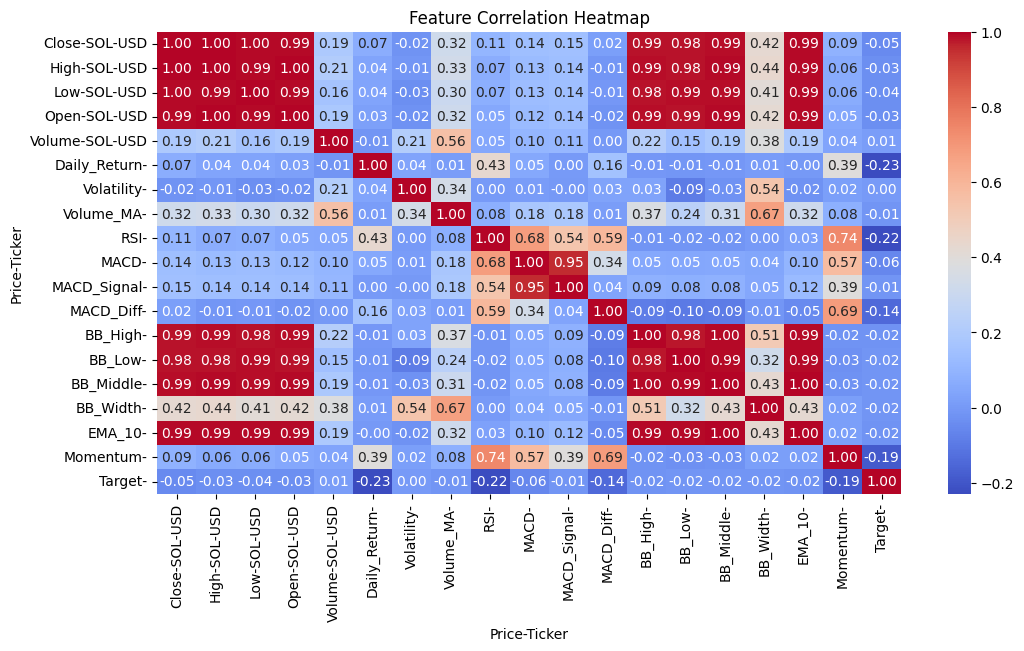

In [24]:
# Correlation Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

**Plot Close price with SMA_10 and SMA_50**

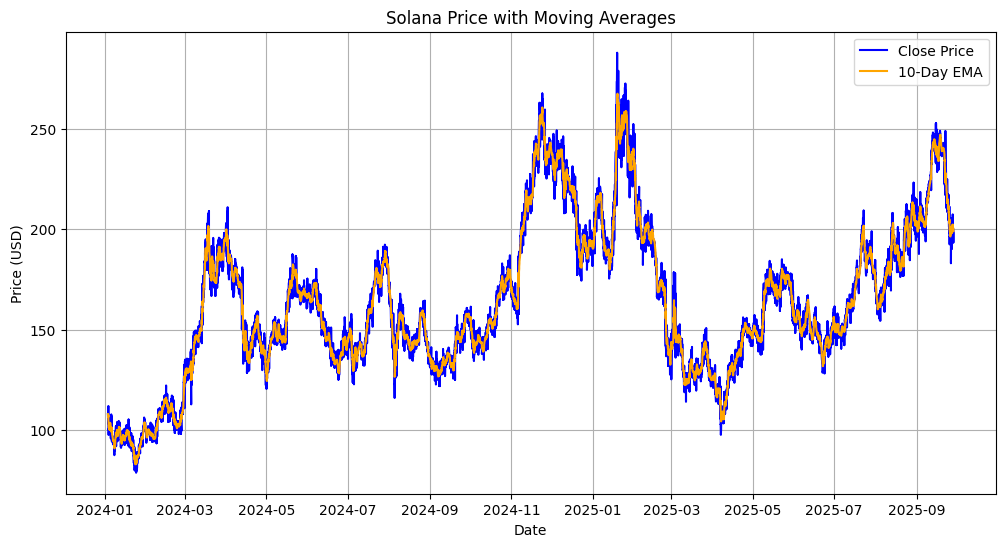

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(solana['Close'], label='Close Price', color='blue')
plt.plot(solana['EMA_10'], label='10-Day EMA', color='orange')
plt.title('Solana Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

**Candlestick-like Line Plot for OHLC (last 30 days)**

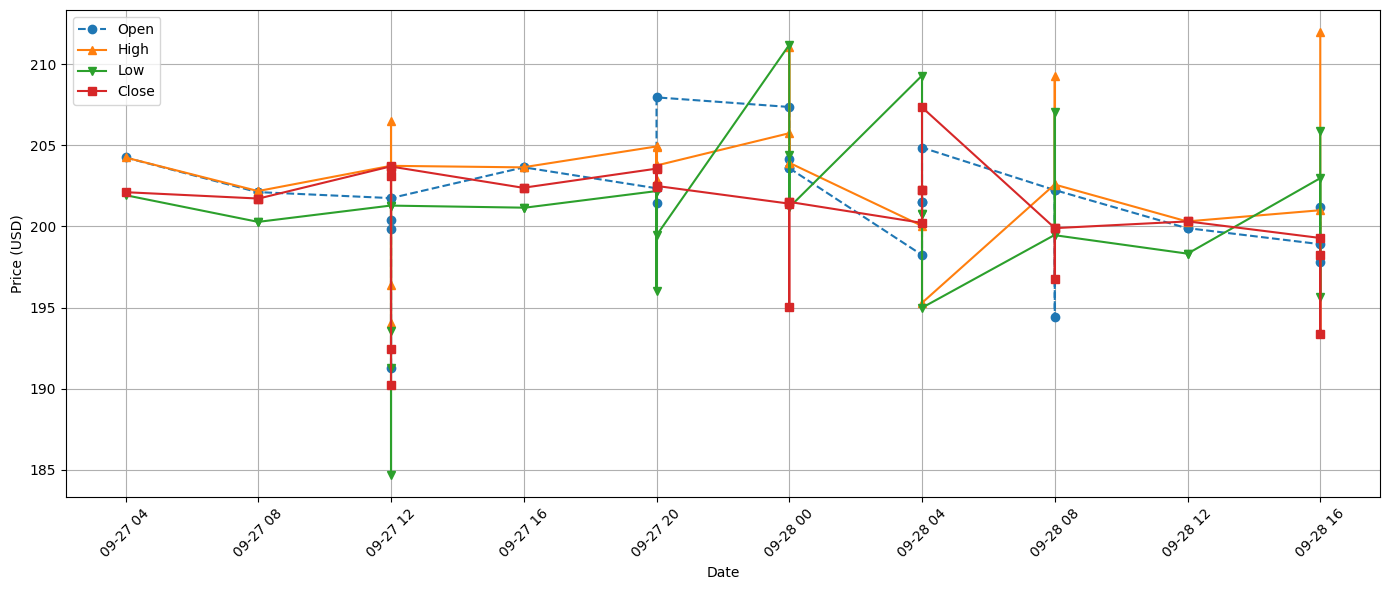

In [26]:
solana_last_month = solana[-30:]

plt.figure(figsize=(14, 6))
plt.plot(solana_last_month['Open'], label='Open', linestyle='--', marker='o')
plt.plot(solana_last_month['High'], label='High', linestyle='-', marker='^')
plt.plot(solana_last_month['Low'], label='Low', linestyle='-', marker='v')
plt.plot(solana_last_month['Close'], label='Close', linestyle='-', marker='s')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Normalize the Feature Values**

In [27]:
features = [
    'RSI',
    'MACD_Diff',
    'BB_Width',
    'EMA_10',
    'Momentum'
]

In [28]:
target = 'Target'

data = solana[features + [target]].copy()

In [29]:
from xgboost import XGBRegressor
xgb = XGBRegressor().fit(solana[features], solana['Close'])
solana['XGB_Features'] = xgb.predict(solana[features])

/tmp/ipython-input-2749601349.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  solana['XGB_Features'] = xgb.predict(solana[features])


In [30]:
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(data[features])
target_values = data[target].values

# **Create Sequences for LSTM**

In [31]:
def create_sequences(features, target, sequence_length=60):
    X, y = [], []
    for i in range(sequence_length, len(features)):
        X.append(features[i-sequence_length:i])
        y.append(target[i])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_features, target_values, sequence_length)

In [32]:
solana['Target'].value_counts()

,count
Target,
1,4773
0,4743


# **Split into Train and Test Sets**

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7564, 60, 5)
y_train shape: (7564,)
X_test shape: (1892, 60, 5)
y_test shape: (1892,)


# **Build and Train the LSTM Model**

In [34]:
time_steps = 60

In [35]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, len(features))),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

# **Train the model**

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

In [39]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [40]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.4800 - loss: 0.6957 - val_accuracy: 0.5175 - val_loss: 0.6928
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.5047 - loss: 0.6931 - val_accuracy: 0.5089 - val_loss: 0.6938
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.4890 - loss: 0.6943 - val_accuracy: 0.5030 - val_loss: 0.6931
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.4903 - loss: 0.6936 - val_accuracy: 0.5089 - val_loss: 0.6929
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5014 - loss: 0.6936 - val_accuracy: 0.5089 - val_loss: 0.6930
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5123 - loss: 0.6935 - val_accuracy: 0.4911 - val_loss: 0.6937


# **Plot Models Performance**

**Plot Accuracy**

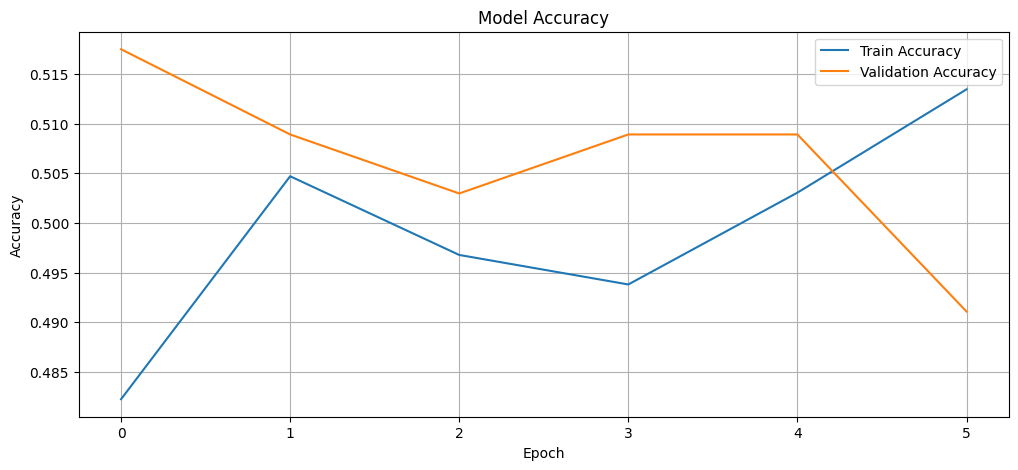

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Plot Loss**

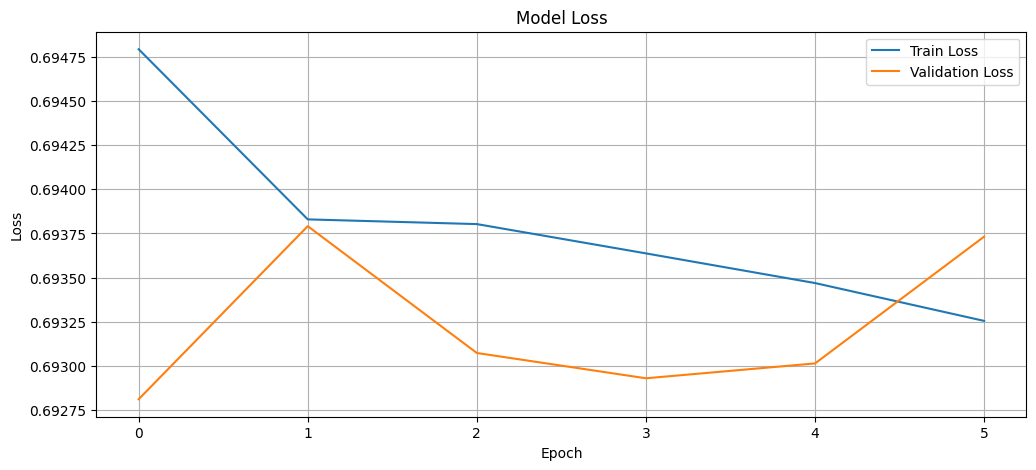

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# **Predicting Next Move**

In [43]:
solana_scaled = pd.DataFrame(scaled_features, columns=features, index=solana.index)
solana_scaled['Target'] = solana['Target']

In [44]:
time_steps = 60

In [45]:
latest_input = solana_scaled[features].iloc[-time_steps:].values
latest_input = np.expand_dims(latest_input, axis=0)

prob_up = model.predict(latest_input)[0][0]
print(f"Probability Price Goes UP Tomorrow: {prob_up:.2f}")
print(f"Probability Price Goes DOWN Tomorrow: {1 - prob_up:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Probability Price Goes UP Tomorrow: 0.50
Probability Price Goes DOWN Tomorrow: 0.50
